# Example 1: Symbolic Regressor

In [1]:
import sys
import os
from pathlib import Path
# Add the parent folder (my_project) to Python's search path
sys.path.append(str(Path.cwd().parent))

%matplotlib inline
from gplearn.genetic_pmm import SymbolicRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.utils.random import check_random_state
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import pandas as pd
import graphviz
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
import math
from collections import defaultdict
import graphviz

os.environ["PATH"] += os.pathsep + r'C:\Program Files\Graphviz\bin'

In [2]:
def get_benchmark_dataset(name, n_train=100, n_test=100, random_state=0):
    """
    Generates train and test datasets for standard Genetic Programming benchmarks.

    Parameters:
        name (str): Benchmark problem ('E1', 'E2', 'M1', 'M2', 'H1', 'H2')
        n_train (int): Number of training samples
        n_test (int): Number of testing samples
        random_state (int/RandomState): Seed for reproducibility

    Returns:
        X_train, y_train, X_test, y_test
    """
    rng = check_random_state(random_state)
    name = name.upper().replace("-", "").replace("_", "")

    def _generate_data(n_samples):

        # 1. Custom Domain Handling
        if name == 'NGUYEN7':
            # Sampling x from [0, 2] to prevent log(x + 1) domain errors (x <= -1)
            X = rng.uniform(0, 2, n_samples * 5).reshape(-1, 5)
        elif name == 'KEIJZER6':
            # Sampling positive values [1, 100] for harmonic number calculations
            X = rng.uniform(1, 100, n_samples * 5).reshape(-1, 5)
        else:
            # Default standard domain [-5, 5]
            X = rng.uniform(-5, 5, n_samples * 5).reshape(-1, 5)

        x1, x2, x3, x4, x5 = X[:, 0], X[:, 1], X[:, 2], X[:, 3], X[:, 4]

        # Define Function

        if name == 'F1':
            y = (x1 + 1) * (x2 +2) * (x3 +3) * (x4 +4) * (x5 +5)
        elif name == 'F2':
            y = (1 / (1 + x1**-4)) + (1 / (1 + x2**-4)) + (1 / (1 + x3**-4)) + (1 / (1 + x4**-4)) + (1 / (1 + x5**-4))
        elif name == 'F3':
            y = np.sin(x1) * np.sin(x1 + x1**2)
        elif name == 'F4':
            y = x1 + x2 + x3 +x4 + x5
        elif name == 'F5':
            y = x1**5 + x2**4 + x3**3 + x4**2 + x1**1

        # 2. Koza Benchmark Suite
        elif name == 'KOZA1':
            y = x1**4 + x1**3 + x1**2 + x1
        elif name == 'KOZA2':
            y = x1**5 - 2 * (x1**3) + x1
        elif name == 'KOZA3':
            y = x1**6 - 2 * (x1**4) + x1**2

        # 3. Nguyen Benchmark Suite
        elif name == 'NGUYEN1':
            y = x1**3 + x1**2 + x1
        elif name == 'NGUYEN3':
            y = x1**5 + x1**4 + x1**3 + x1**2 + x1
        elif name == 'NGUYEN5':
            y = np.sin(x1**2) * np.cos(x1) - 1
        elif name == 'NGUYEN6':
            y = np.sin(x1) * np.sin(x1 + x1**2)
        elif name == 'NGUYEN7':
            y = np.log(x1 + 1) + np.log(x1**2 + 1)
        elif name == 'NGUYEN10':
            y = np.sin(x1) + np.sin(x2**2)

        # 4. Pagie Polynomial
        elif name == 'PAGIE1':
            y = (1 / (1 + x1**-4)) + (1 / (1 + x2**-4))

        # 5. Keijzer Suite
        elif name == 'KEIJZER6':
            # Harmonic sum: sum_{i=1..x1} (1 / i)
            y = np.array([sum(1.0 / i for i in range(1, int(val) + 1)) for val in x1])

        # 6. Vladislavleva Suite
        elif name == 'VLADISLAVLEVA1':
            y = np.exp(-(x1 - 1)**2) * np.cos(x2)

        else:
            raise ValueError(f"Unknown benchmark name: '{name}'. Choose from 'E1', 'E2', 'M1', 'M2', 'H1', 'H2'.")

        return X, y

    X_train, y_train = _generate_data(n_train)
    X_test, y_test = _generate_data(n_test)

    return X_train, y_train, X_test, y_test

In [3]:
def plot_all_benchmarks_histogram(n_samples=10000, random_state=42, benchmarks = []):
    """
    Plots a 2x3 grid of histograms showing target distributions across all benchmark functions.
    """
    fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 5 * rows))
    axes = axes.flatten()

    for idx, b_name in enumerate(benchmarks):
        X_tr, y_tr, _, _ = get_benchmark_dataset(b_name, n_train=n_samples, random_state=random_state)

        # Clip extreme asymptote values for H1/F16 (tan x) so outliers don't flatten the plot
        if b_name == 'H1':
            y_display = np.clip(y_tr, -100, 100)
            title_suffix = " (Clipped [-100, 100])"
        else:
            y_display = y_tr
            title_suffix = ""

        ax = axes[idx]
        sns.histplot(y_display, bins=50, kde=True, ax=ax, color='skyblue', edgecolor='black', alpha=0.7)

        # Summary stats in title
        ax.set_title(
            f"Benchmark {b_name}{title_suffix}\nMean: {np.mean(y_tr):.2f} | Std: {np.std(y_tr):.2f}",
            fontsize=11,
            fontweight='bold'
        )
        ax.set_xlabel("Target Response (y)")
        ax.set_ylabel("Count")

    plt.tight_layout()
    plt.show()

# Run combined plotting function
# plot_all_benchmarks_histogram(benchmarks=benchmarks)

In [4]:
benchmarks = [
    'koza-1', 'koza-2', 'koza-3',
    # 'NGUYEN1', 'NGUYEN3', 'NGUYEN5',
    # 'NGUYEN6', 'NGUYEN7', 'NGUYEN10',
    # 'PAGIE1', 'KEIJZER6', 'VLADISLAVLEVA1',
]

total_run = len(benchmarks)
cols = 3
rows = math.ceil(total_run / cols)


In [5]:
# Training Settings

def get_params(random_seed):
    return dict(
    population_size=100,
    generations=50,
    stopping_criteria=0.005,
    tournament_size= 20,
    p_crossover=0.7,
    p_subtree_mutation=0.1,
    p_hoist_mutation=0.05,
    p_point_mutation=0.1,
    max_samples=1.0,
    verbose=1,
    parsimony_coefficient=0.005,
    # parsimony_coefficient=0.01,
    random_state=random_seed,
    metric='rmse',
    function_set = ('add', 'sub', 'mul','div', 'sqrt', 'log',
                    'abs', 'neg', 'inv',
                    'max', 'min',
                    'sin', 'cos', 'tan'
                    ),

    prey_n_elites=1,
        predator_n_elites=1,

    predator_population_size= 50,
        catch_penalty= 1.00,
        catch_num= 5,
        catch_size= 20,

    prey_competitive_consts = 1,
        predator_competitive_consts = 1,

    data_record_diversity_distance = True,
        data_record_diversity_entropy = True,

)

seed_number = 4
is_skip = False
line_alpha =0.75

master_rng = np.random.default_rng(seed=42)
random_seeds = master_rng.integers(low=0, high=10000, size= seed_number).tolist()
print(f"Random Seeds = {random_seeds}")
# random_seeds = [0]

Random Seeds = [892, 7739, 6545, 4388]


In [6]:
new_result = []
is_break = False

for seed in random_seeds:
    print(f"\n==================== SEED {seed} ====================")

    for name in benchmarks:
        # 1. Load dataset using the current seed
        X_train, y_train, X_test, y_test = get_benchmark_dataset(name, random_state=seed)

        # 2. Instantiate GP with current random_state
        est_gp = SymbolicRegressor(**get_params(seed))
        print(f"\n====================================================================================")
        print(f"Benchmark Running = {name} with Seed {seed}")

        # 3. Train GP
        est_gp.fit(X_train, y_train)
        print(f"Formula: {str(est_gp._program)}")

        # 4. Predict and clean numerical issues
        y_pred = est_gp.predict(X_test)
        y_pred = np.nan_to_num(y_pred, nan=0.0, posinf=1e5, neginf=-1e5)

        # 5. Calculate Test R2
        r2 = r2_score(y_test, y_pred)
        r2_scores = [r2_score(y_train, program.execute(X_train)) for program in est_gp.best_programs_per_gen]


        # 6. Record findings
        new_result.append({
            'Seed': seed,
            'Benchmark': name,
            'R2_Score': r2,
            'Formula': str(est_gp._program),

            # Data Per Generation
            'R2 Score Per Gen': r2_scores,

            'Prey Average Length': est_gp.run_details_['average_length'],
            'Prey Average Fitness': est_gp.run_details_['average_fitness'],
            'Prey Best Fitness': est_gp.run_details_['best_fitness'],
            'Prey Best Length': est_gp.run_details_['best_length'],

            'Predator Average Length': est_gp.run_details_['pred_average_length'],
            'Predator Average Fitness': est_gp.run_details_['pred_average_fitness'],
            'Predator Best Fitness': est_gp.run_details_['pred_best_fitness'],
            'Predator Best Length': est_gp.run_details_['pred_best_length'],

            'Prey Diversity Distance': est_gp.run_details_['prey_diversity_distance'],
            'Prey Diversity Entropy': est_gp.run_details_['prey_diversity_entropy'],
            'Predator Diversity Distance': est_gp.run_details_['pred_diversity_distance'],
            'Predator Diversity Entropy': est_gp.run_details_['pred_diversity_entropy'],

        })

        if r2 < 0.6 and is_skip:
            is_break = True
            break

    if (is_break and is_skip): break



==================== SEED 892 ====================

Benchmark Running = koza-1 with Seed 892
    |   Population Average    |             Best Individual              |
---- ------------------------- ------------------------------------------ ----------
 Gen   Length          Fitness   Length          Fitness      OOB Fitness  Time Left
   0     9.27          208.483       10          201.751              N/A      8.07s
   1     9.15          208.136       10          201.751              N/A     33.86s
   2     9.56          208.035       10          201.751              N/A     26.90s
   3     8.22          208.029       10          201.751              N/A     28.93s
   4     8.40          224.582       10          201.751              N/A     18.43s
   5     7.93          208.073       10          201.751              N/A     16.26s
   6     8.99          208.127       10          201.751              N/A     19.09s
   7     8.49          210.354       10          201.751          


--- Summary Performance across seeds ---
  Benchmark      mean       std
0    koza-1  0.543476  0.358971
1    koza-2 -0.480768  1.793655
2    koza-3 -0.129893  0.205658


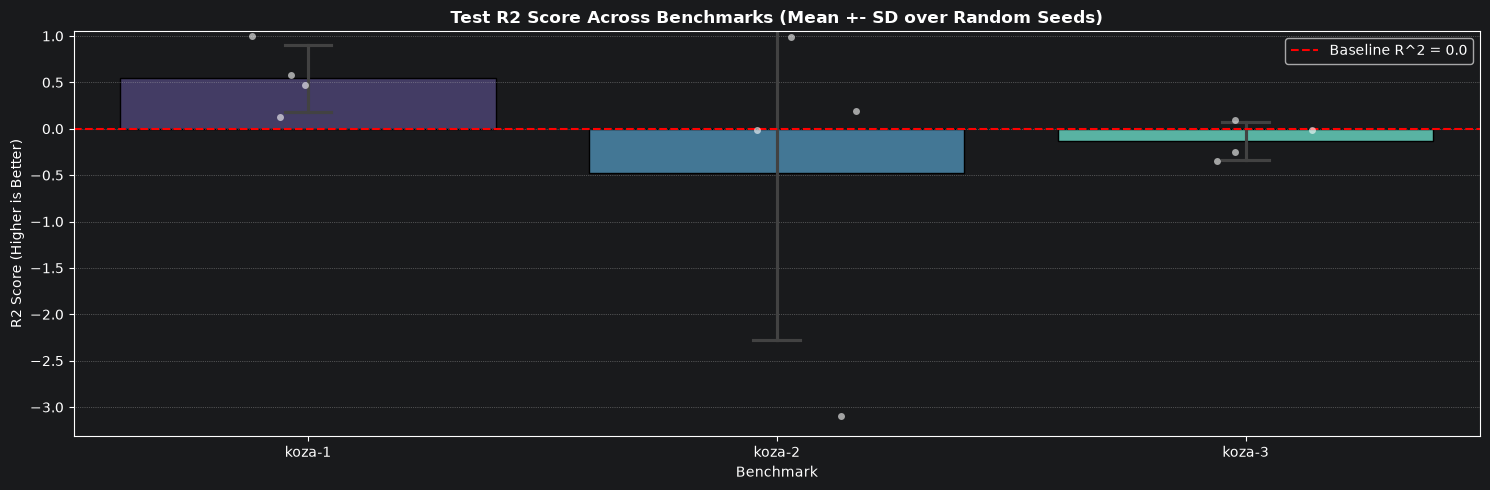

In [7]:
# Convert results into a DataFrame
df_results = pd.DataFrame(new_result)

# Display summary table with mean and standard deviation across seeds
df_summary = df_results.groupby('Benchmark')['R2_Score'].agg(['mean', 'std']).reset_index()
print("\n--- Summary Performance across seeds ---")
print(df_summary)

# Plot Bar Chart comparison across benchmarks with error bars (representing variability across seeds)
plt.figure(figsize=(15, 5))
sns.barplot(
    data=df_results,
    x='Benchmark',
    y='R2_Score',
    hue='Benchmark',
    palette='mako',
    errorbar='sd',       # Shows standard deviation across seeds
    capsize=0.1,         # Adds caps to error bars
    legend=False,
    edgecolor='black'
)

# Overlay individual seed points
sns.stripplot(
    data=df_results,
    x='Benchmark',
    y='R2_Score',
    color='white',
    alpha=0.6,
    jitter=0.2,
    size=5
)

plt.axhline(0, color='red', linestyle='--', label='Baseline R^2 = 0.0')
plt.ylim(top=1.05)
plt.title('Test R2 Score Across Benchmarks (Mean +- SD over Random Seeds)', fontsize=12, fontweight='bold')
plt.ylabel('R2 Score (Higher is Better)')
plt.grid(axis='y', linestyle=':', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()

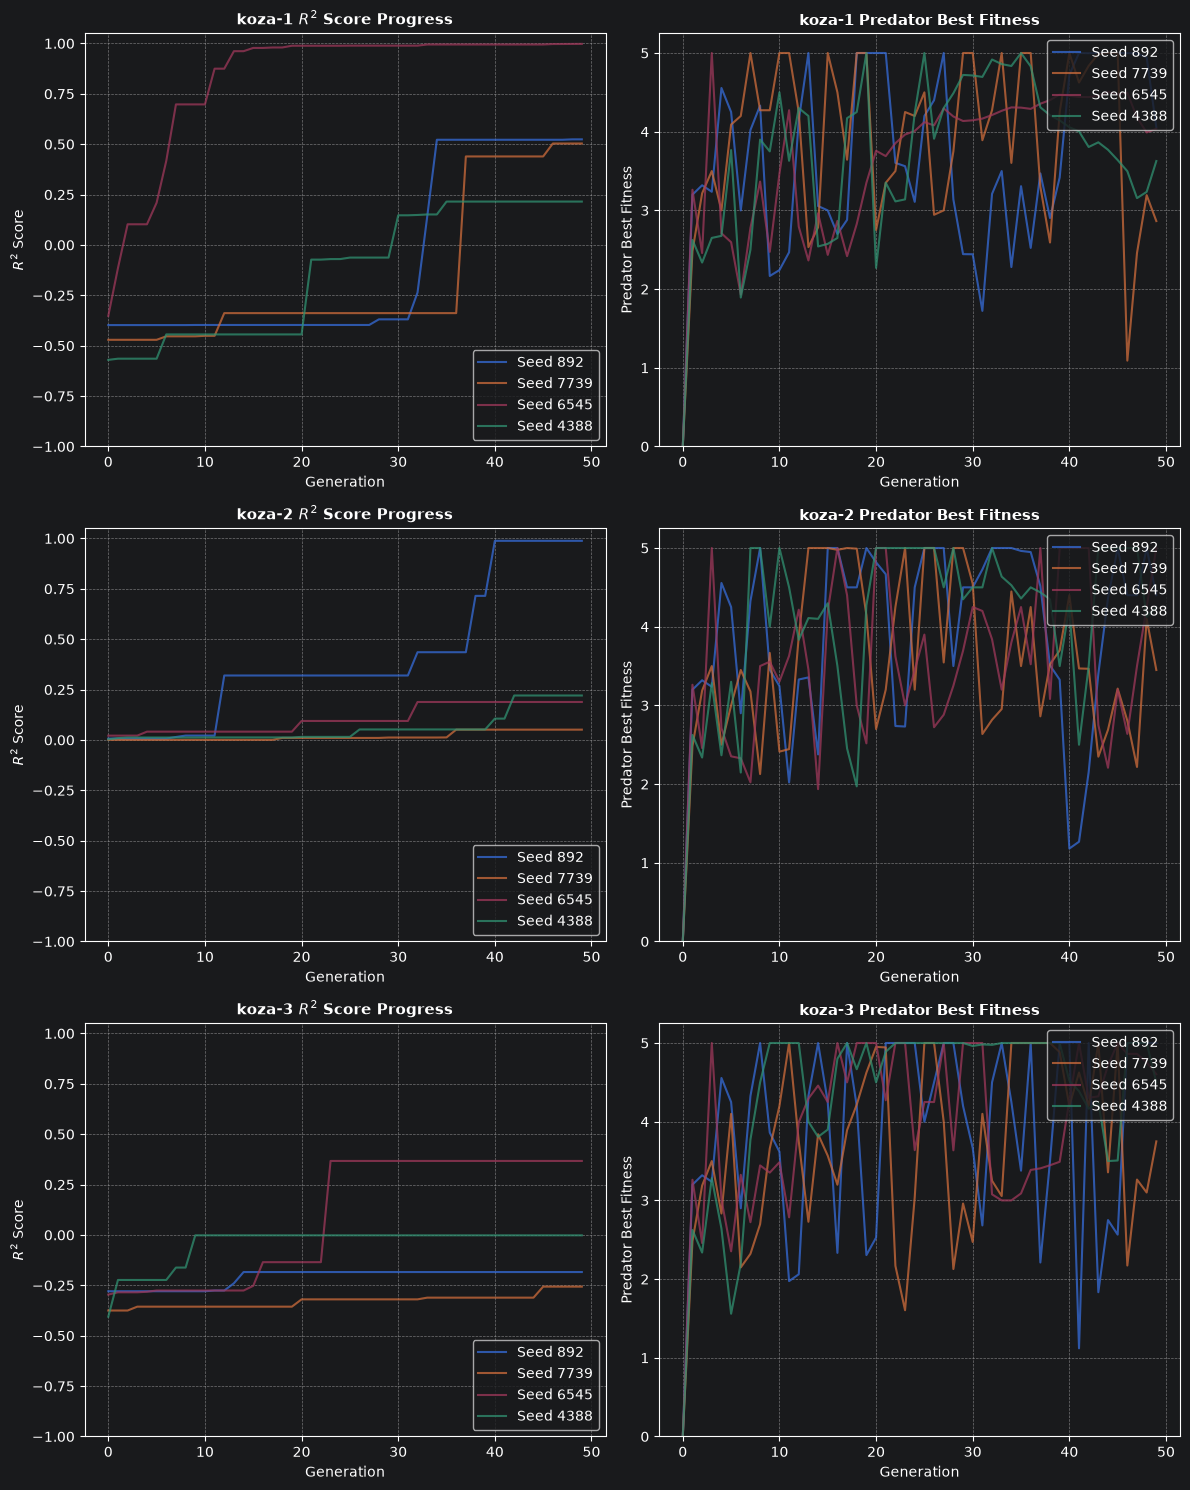

In [8]:
# Plot Fitness of Prey VS Predator

# 1. Group records by benchmark name directly from new_result
benchmark_groups = defaultdict(list)
for record in new_result:
    benchmark_groups[record["Benchmark"]].append(record)

# 2. Set up subplots dynamically based on benchmark count
n_benchmarks = len(benchmark_groups)
fig, axes = plt.subplots(
    n_benchmarks, 2, figsize=(12, 5 * n_benchmarks), squeeze=False
)

# 3. Iterate through grouped data
for row_idx, (b_name, records) in enumerate(benchmark_groups.items()):
    ax_r2 = axes[row_idx, 0]
    ax_prd_fitness = axes[row_idx, 1]

    for record in records:
        seed = record["Seed"]
        prey_fitness = record["R2 Score Per Gen"]
        predator_fitness = record["Predator Best Fitness"]

        # Plot Prey R2 Score on Left Subplot
        ax_r2.plot(
            range(len(prey_fitness)),
            prey_fitness,
            linewidth=1.5,
            label=f"Seed {seed}",
            alpha= line_alpha,
        )

        # Plot Predator Fitness on Right Subplot
        ax_prd_fitness.plot(
            range(len(predator_fitness)),
            predator_fitness,
            linewidth=1.5,
            label=f"Seed {seed}",
            alpha= line_alpha,
        )

    # Formatting Left (Prey R2 Score)
    ax_r2.set_title(
        f"{b_name} $R^2$ Score Progress", fontsize=11, fontweight="bold"
    )
    ax_r2.set_xlabel("Generation")
    ax_r2.set_ylabel("$R^2$ Score")
    ax_r2.set_ylim(-1, 1.05)
    ax_r2.grid(True, linestyle="--", alpha=0.6)
    ax_r2.legend(loc="lower right")

    # Formatting Right (Predator Fitness)
    ax_prd_fitness.set_title(
        f"{b_name} Predator Best Fitness", fontsize=11, fontweight="bold"
    )
    ax_prd_fitness.set_xlabel("Generation")
    ax_prd_fitness.set_ylabel("Predator Best Fitness")
    ax_prd_fitness.set_ylim(bottom=0)
    ax_prd_fitness.grid(True, linestyle="--", alpha=0.6)
    ax_prd_fitness.legend(loc="upper right")

plt.tight_layout()
plt.show()

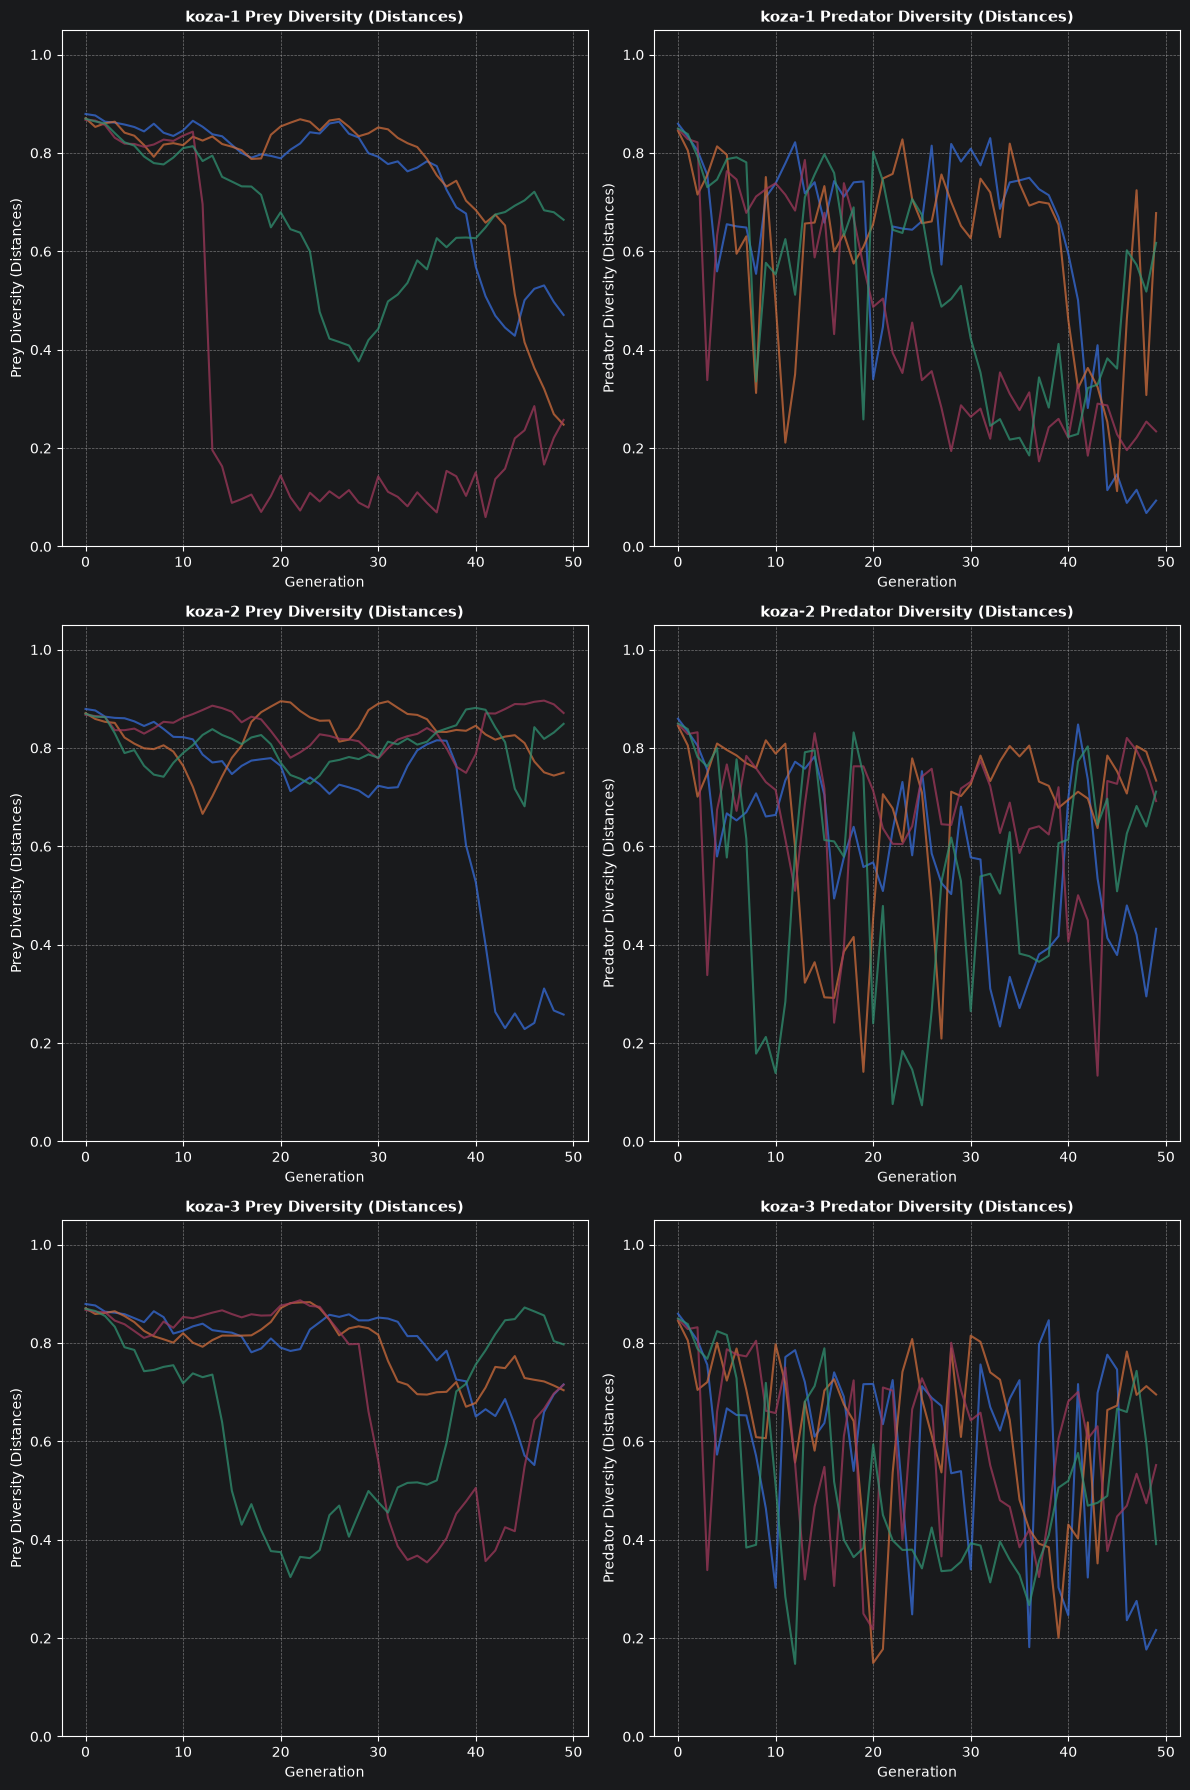

In [9]:
# Plot Distance Diversity of Prey VS Predator

# 1. Group records by benchmark name directly from new_result
benchmark_groups = defaultdict(list)
for record in new_result:
    benchmark_groups[record["Benchmark"]].append(record)

# 2. Set up subplots dynamically based on benchmark count
n_benchmarks = len(benchmark_groups)
fig, axes = plt.subplots(n_benchmarks, 2, figsize=(12, 6 * n_benchmarks), squeeze=False)

for row_idx, (b_name, records) in enumerate(benchmark_groups.items()):
    ax_prey_dist = axes[row_idx, 0]
    ax_prd_dist = axes[row_idx, 1]

    for record in records:
        seed = record["Seed"]
        prey_dist = record["Prey Diversity Distance"]
        prd_dist = record["Predator Diversity Distance"]

        # Plot Diversity
        ax_prey_dist.plot(range(len(prey_dist)), prey_dist, linewidth=1.5, label=f'Seed {seed}', alpha= line_alpha)
        ax_prd_dist.plot(range(len(prd_dist)), prd_dist, linewidth=1.5, label=f'Seed {seed}', alpha= line_alpha)

    # Formatting Left
    ax_prey_dist.set_title(f'{b_name} Prey Diversity (Distances)', fontsize=11, fontweight='bold')
    ax_prey_dist.set_xlabel('Generation')
    ax_prey_dist.set_ylabel('Prey Diversity (Distances)')
    ax_prey_dist.set_ylim(0, 1.05)
    ax_prey_dist.grid(True, linestyle='--', alpha=0.6)

    # Formatting Right
    ax_prd_dist.set_title(f'{b_name} Predator Diversity (Distances)', fontsize=11, fontweight='bold')
    ax_prd_dist.set_xlabel('Generation')
    ax_prd_dist.set_ylabel('Predator Diversity (Distances)')
    ax_prd_dist.set_ylim(0, 1.05)
    ax_prd_dist.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

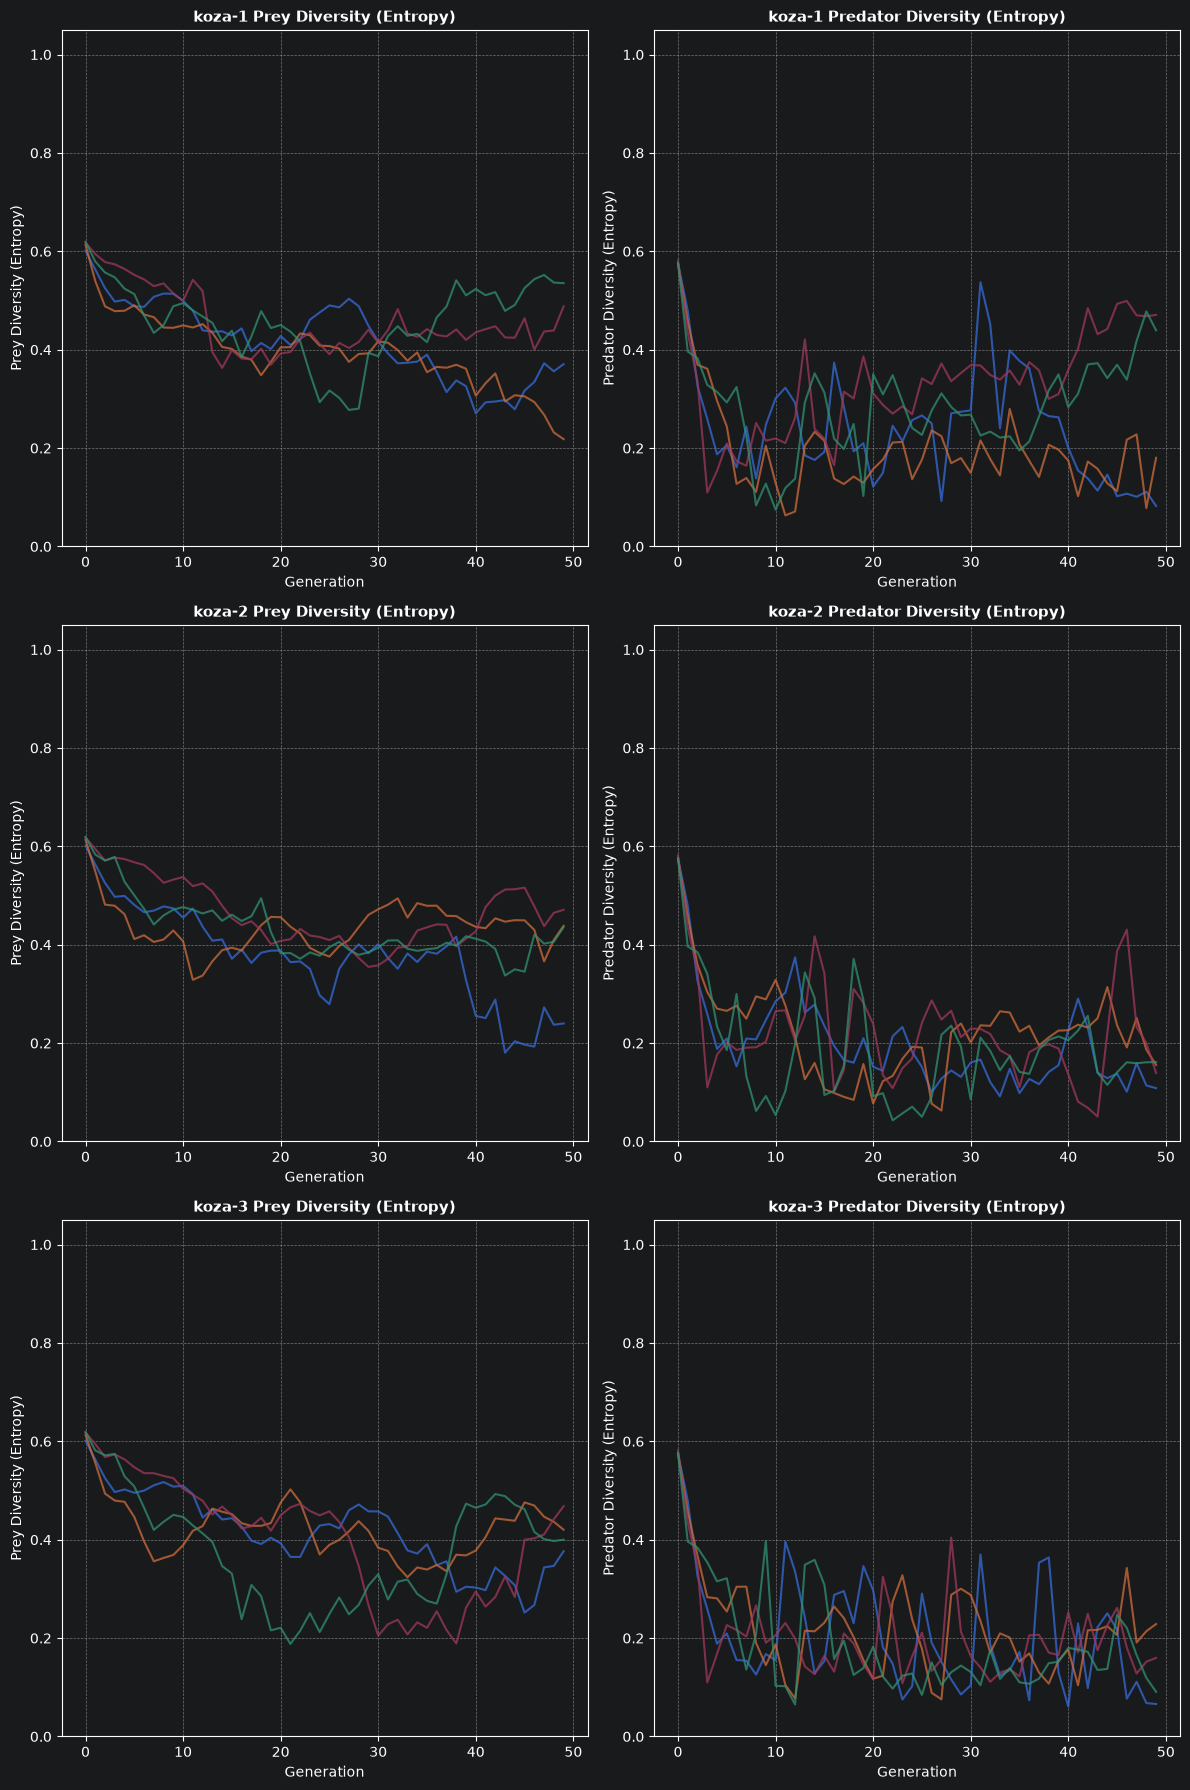

In [10]:
# Plot Entropy Diversity of Prey VS Predator

# 1. Group records by benchmark name directly from new_result
benchmark_groups = defaultdict(list)
for record in new_result:
    benchmark_groups[record["Benchmark"]].append(record)

# 2. Set up subplots dynamically based on benchmark count
n_benchmarks = len(benchmark_groups)
fig, axes = plt.subplots(n_benchmarks, 2, figsize=(12, 6 * n_benchmarks), squeeze=False)

for row_idx, (b_name, records) in enumerate(benchmark_groups.items()):
    ax_prey_dist = axes[row_idx, 0]
    ax_prd_dist = axes[row_idx, 1]

    for record in records:
        seed = record["Seed"]
        prey_dist = record["Prey Diversity Entropy"]
        prd_dist = record["Predator Diversity Entropy"]

        # Plot Diversity
        ax_prey_dist.plot(range(len(prey_dist)), prey_dist, linewidth=1.5, label=f'Seed {seed}', alpha= line_alpha)
        ax_prd_dist.plot(range(len(prd_dist)), prd_dist, linewidth=1.5, label=f'Seed {seed}', alpha= line_alpha)

    # Formatting Left
    ax_prey_dist.set_title(f'{b_name} Prey Diversity (Entropy)', fontsize=11, fontweight='bold')
    ax_prey_dist.set_xlabel('Generation')
    ax_prey_dist.set_ylabel('Prey Diversity (Entropy)')
    ax_prey_dist.set_ylim(0, 1.05)
    ax_prey_dist.grid(True, linestyle='--', alpha=0.6)

    # Formatting Right
    ax_prd_dist.set_title(f'{b_name} Predator Diversity (Entropy)', fontsize=11, fontweight='bold')
    ax_prd_dist.set_xlabel('Generation')
    ax_prd_dist.set_ylabel('Predator Diversity (Entropy)')
    ax_prd_dist.set_ylim(0, 1.05)
    ax_prd_dist.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

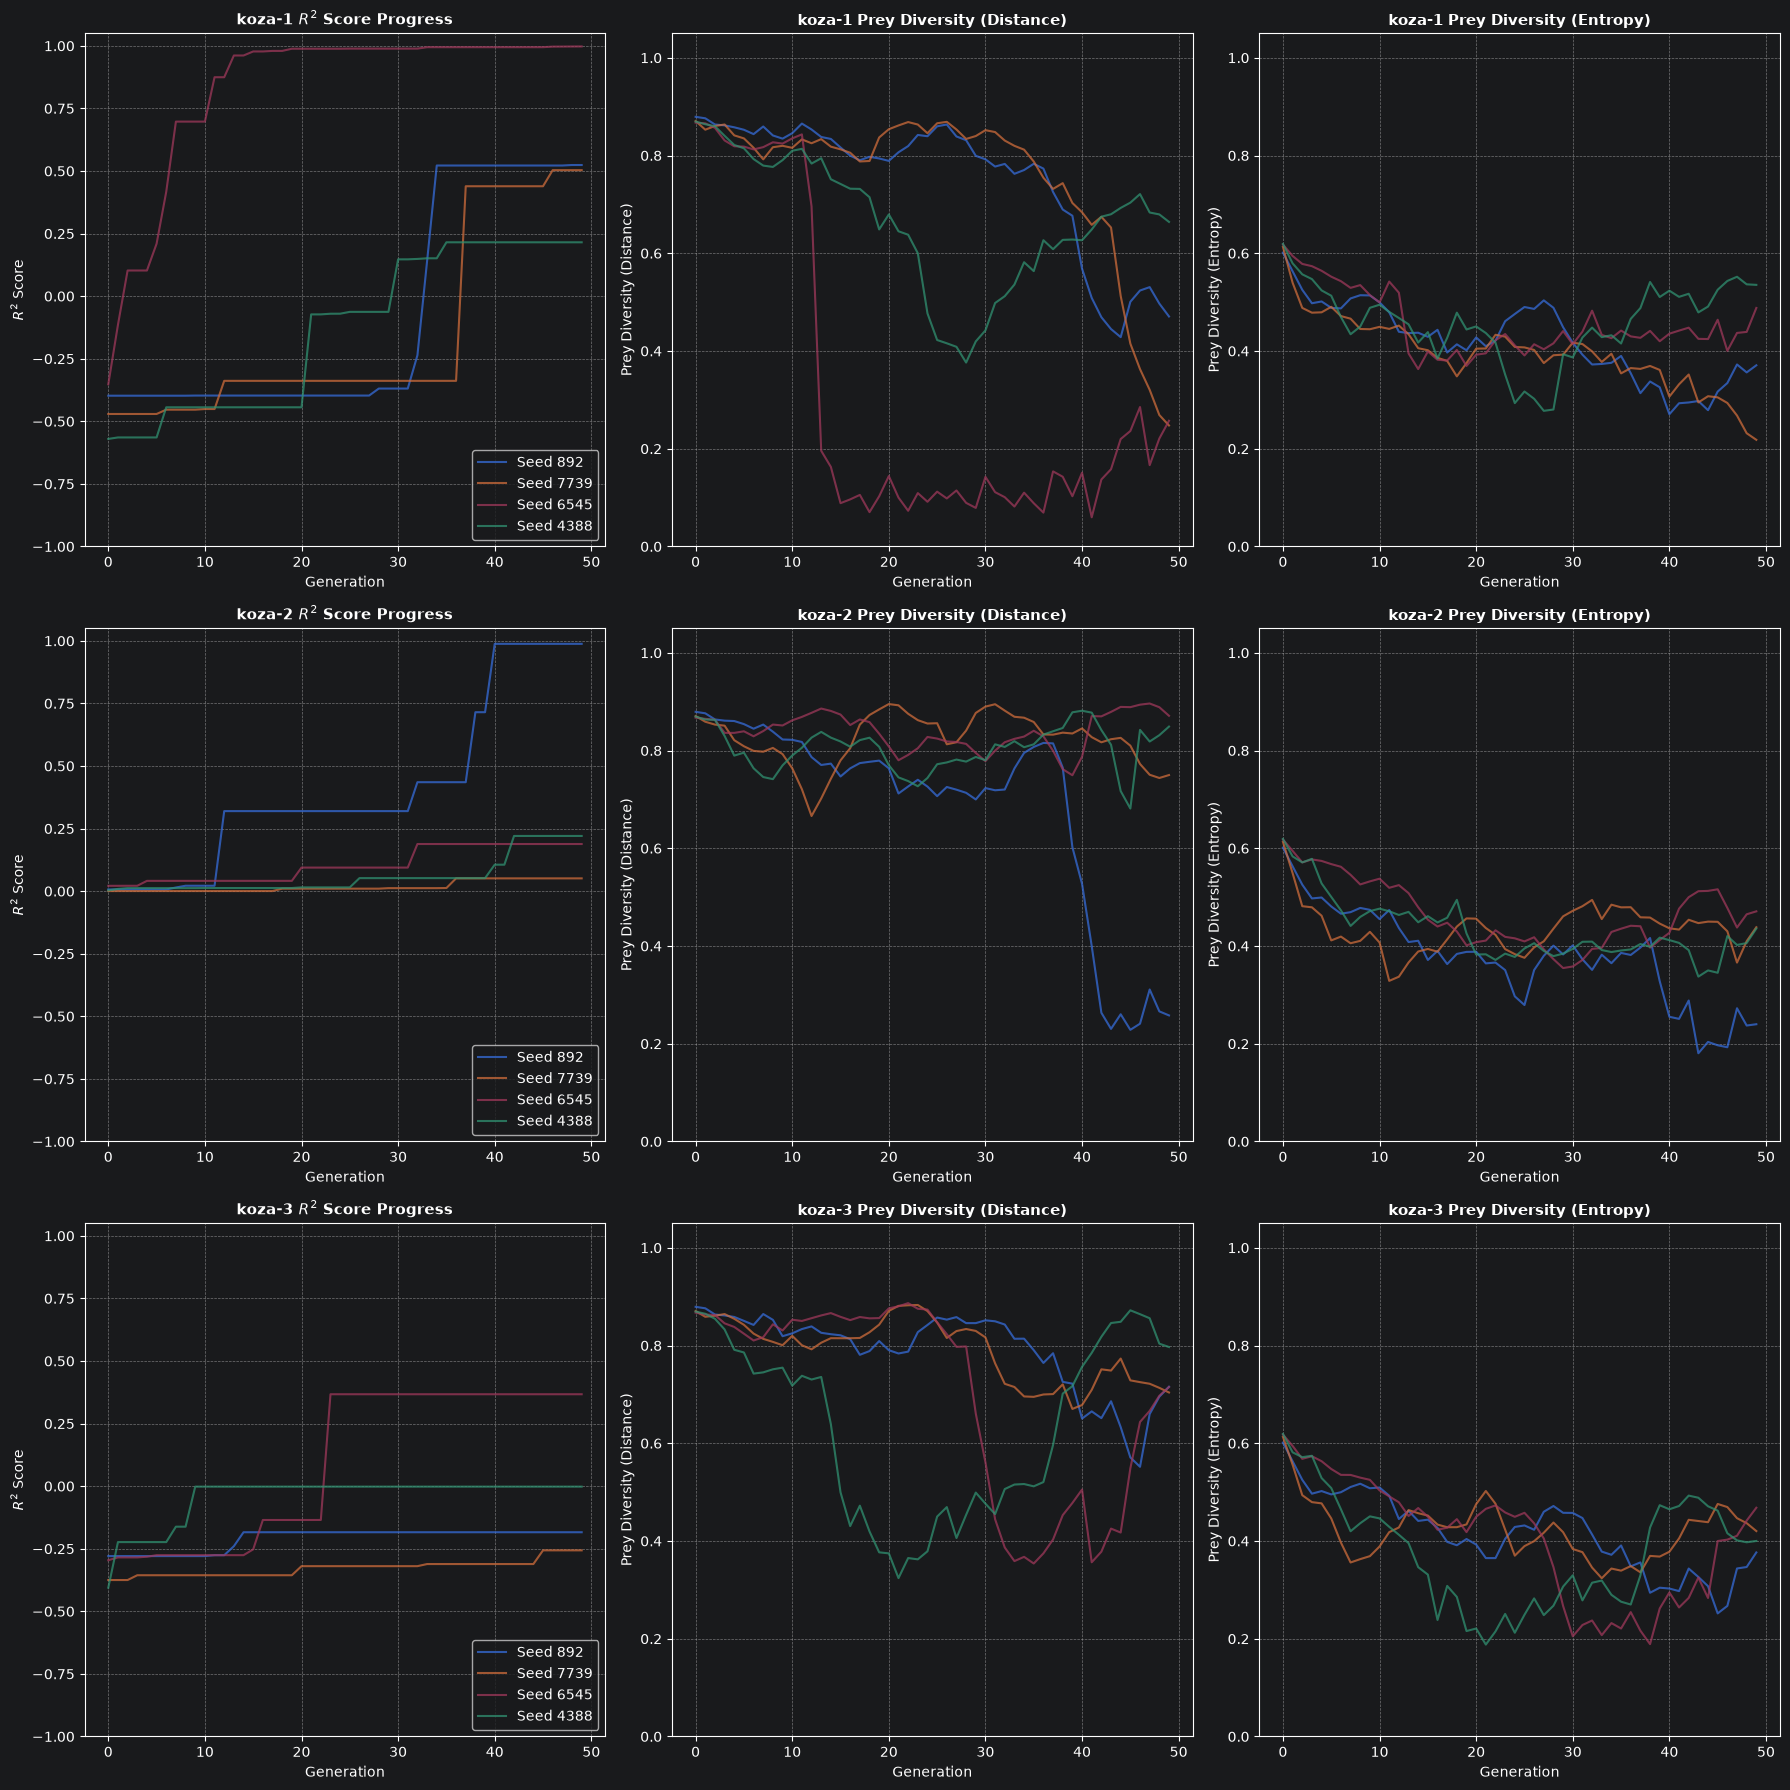

In [11]:
# Plot Prey Fitness vs Diversity (Distances)

# 1. Group records by benchmark name directly from new_result
benchmark_groups = defaultdict(list)
for record in new_result:
    benchmark_groups[record["Benchmark"]].append(record)

# 2. Set up subplots dynamically based on benchmark count
n_benchmarks = len(benchmark_groups)
fig, axes = plt.subplots(n_benchmarks, 3, figsize=(18, 6 * n_benchmarks), squeeze=False)

for row_idx, (b_name, records) in enumerate(benchmark_groups.items()):
    ax_r2 = axes[row_idx, 0]
    ax_prey_diver_distance = axes[row_idx, 1]
    ax_prey_diver_entropy = axes[row_idx, 2]

    for record in records:
        seed = record["Seed"]
        prey_fitness = record["R2 Score Per Gen"]
        prey_diversity_distance = record["Prey Diversity Distance"]
        prey_diversity_entropy = record['Prey Diversity Entropy']

        # Plot Prey R2 Score on Left Subplot
        ax_r2.plot(
            range(len(prey_fitness)),
            prey_fitness,
            linewidth=1.5,
            label=f"Seed {seed}",
            alpha= line_alpha,
        )

        ax_prey_diver_distance.plot(
            range(len(prey_diversity_distance)),
            prey_diversity_distance,
            linewidth=1.5,
            label=f'Seed {seed}',
            alpha= line_alpha
        )

        ax_prey_diver_entropy.plot(
            range(len(prey_diversity_entropy)),
            prey_diversity_entropy,
            linewidth=1.5,
            label=f'Seed {seed}',
            alpha= line_alpha
        )

    # Formatting Left (Prey R2 Score)
    ax_r2.set_title(
        f"{b_name} $R^2$ Score Progress", fontsize=11, fontweight="bold"
    )
    ax_r2.set_xlabel("Generation")
    ax_r2.set_ylabel("$R^2$ Score")
    ax_r2.set_ylim(-1, 1.05)
    ax_r2.grid(True, linestyle="--", alpha=0.6)
    ax_r2.legend(loc="lower right")

    # Formatting Middle (Prey Diversity Distance)
    ax_prey_diver_distance.set_title(f'{b_name} Prey Diversity (Distance)', fontsize=11, fontweight='bold')
    ax_prey_diver_distance.set_xlabel('Generation')
    ax_prey_diver_distance.set_ylabel('Prey Diversity (Distance)')
    ax_prey_diver_distance.set_ylim(0, 1.05)
    ax_prey_diver_distance.grid(True, linestyle='--', alpha=0.6)

    # Formatting Left
    ax_prey_diver_entropy.set_title(f'{b_name} Prey Diversity (Entropy)', fontsize=11, fontweight='bold')
    ax_prey_diver_entropy.set_xlabel('Generation')
    ax_prey_diver_entropy.set_ylabel('Prey Diversity (Entropy)')
    ax_prey_diver_entropy.set_ylim(0, 1.05)
    ax_prey_diver_entropy.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()